# Análisis Exploratorio de Datos (EDA) — Alojamientos Turísticos StaySpain
**Analista: Patricia Proniewska | 27 Abril 2026**

---

## Índice
1. Objetivos
2. Configuración y conexión a la base de datos
3. Descripción del dataset
4. Información general del dataset
5. Valores nulos
6. Descripción estadística
7. EDA automático con Sweetviz
8. Distribuciones de variables numéricas
9. Distribuciones de variables categóricas
10. Detección de outliers
11. Correlaciones
12. Conclusiones

## 1. Objetivos

El objetivo de esta EDA es explorar el dataset de alojamientos turísticos de StaySpain para obtener una comprensión inicial de la calidad de los datos, las distribuciones de las variables clave y los patrones relevantes para los equipos de Marketing y Experiencia del Cliente.

- Presentar estadísticas descriptivas claras (media, mediana, moda, desviación estándar) que faciliten la comprensión inicial del dataset.
- Identificar valores faltantes y cuantificar su impacto en las variables relevantes.
- Identificar outliers en las variables clave con una estrategia de tratamiento justificada.
- Analizar la relación entre las características de los alojamientos y las variables objetivo de cada área.
- Generar hipótesis de negocio a partir de los patrones observados, que orienten el análisis en profundidad.

## 2. Configuración y conexión a la base de datos

Conexión a la base de datos remota del equipo. Las credenciales se gestionan de forma segura mediante `getpass` — la contraseña nunca queda expuesta en el código.

In [2]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass
# !pip install sweetviz
import sweetviz as sv

# Conexión a la base de datos
password = getpass.getpass("Introduce la contraseña MySQL: ")

conn = mysql.connector.connect(
    host="212.227.90.6",
    user="Equipo26",
    password=password,
    database="Equip_26"
)

df_alojamientos = pd.read_sql("SELECT * FROM Tourist_Accommodation27042026", conn)
conn.close()

print("Conexión exitosa ✅")
print(f"Datos cargados: {df_alojamientos.shape[0]} filas, {df_alojamientos.shape[1]} columnas")

/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_3212/3166057888.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_alojamientos = pd.read_sql("SELECT * FROM Tourist_Accommodation27042026", conn)


Conexión exitosa ✅
Datos cargados: 8000 filas, 35 columnas


## 3. Descripción del dataset

El dataset contiene información sobre alojamientos turísticos publicados en la plataforma StaySpain en 8 ciudades españolas: Barcelona, Girona, Madrid, Málaga, Mallorca, Menorca, Sevilla y Valencia.

Cada fila representa un alojamiento con sus características, disponibilidad y valoraciones de usuarios:

- **apartment_id**: identificador único del alojamiento.
- **name / description**: nombre y descripción del anuncio publicado por el anfitrión.
- **host_id**: identificador del anfitrión.
- **neighbourhood_name / neighbourhood_district**: barrio y distrito del alojamiento.
- **room_type**: tipo de alojamiento (Entire home/apt, Private room, Shared room, Hotel room).
- **accommodates**: número máximo de huéspedes.
- **bathrooms / bedrooms / beds**: características físicas del alojamiento.
- **amenities_list**: lista de servicios y equipamientos incluidos.
- **price**: precio por noche.
- **minimum_nights / maximum_nights**: restricciones de duración de estancia.
- **has_availability**: indica si el alojamiento tiene disponibilidad activa.
- **availability_30/60/90/365**: días disponibles en los próximos 30, 60, 90 y 365 días.
- **number_of_reviews**: número total de reseñas recibidas.
- **first_review_date / last_review_date**: fechas de primera y última reseña.
- **review_scores_rating**: valoración general del alojamiento (escala 0-1000).
- **review_scores_accuracy / cleanliness / checkin / communication / location / value**: dimensiones de valoración.
- **is_instant_bookable**: si el alojamiento permite reserva instantánea.
- **reviews_per_month**: media de reseñas mensuales.
- **country / city**: país y ciudad del alojamiento.
- **insert_date**: fecha de inserción del registro en la base de datos.

> ⚠️ **Nota sobre la escala de valoraciones:** Las variables `review_scores_*` están en escala 0-1000, no 0-100. El umbral mencionado en el enunciado (>80) probablemente corresponde a 800. Pendiente de confirmación con el negocio.

## 4. Información general del dataset

In [ ]:
# Dimensiones y tipos de datos
print(f"Filas: {df_alojamientos.shape[0]} | Columnas: {df_alojamientos.shape[1]}")
print()
df_alojamientos.info()

Filas: 8000 | Columnas: 35

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 8000 non-null   int64  
 1   name                         7997 non-null   object 
 2   description                  7946 non-null   object 
 3   host_id                      8000 non-null   int64  
 4   neighbourhood_name           8000 non-null   object 
 5   neighbourhood_district       4861 non-null   object 
 6   room_type                    8000 non-null   object 
 7   accommodates                 8000 non-null   int64  
 8   bathrooms                    7957 non-null   object 
 9   bedrooms                     7961 non-null   object 
 10  beds                         7992 non-null   float64
 11  amenities_list               7983 non-null   object 
 12  price                        7829 non-null   flo

In [ ]:
# Primeras filas
df_alojamientos.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,None,Private room,2,2,1,...,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1,1,...,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2,...,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2,1,...,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,None,Private room,5,1,2,...,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


In [ ]:
# IDs únicos vs registros totales
total = df_alojamientos.shape[0]
unicos = df_alojamientos['apartment_id'].nunique()
duplicados = total - unicos
print(f"Total registros:           {total}")
print(f"IDs únicos:                {unicos}")
print(f"Registros con ID repetido: {duplicados}")

Total registros:           8000
IDs únicos:                7693
Registros con ID repetido: 307


Los tipos de datos parecen correctos en general. Sin embargo hay variables que requerirán transformación antes del análisis:

- `bathrooms` y `bedrooms` son `varchar` — contienen texto ("1 bath", "Studio") que requiere limpieza para usarlas como numéricas.
- `has_availability` es `varchar` con valores `t`/`f` — pendiente de conversión a booleano.
- Las fechas (`first_review_date`, `last_review_date`, `insert_date`) son `varchar` — pendiente de conversión a tipo fecha.
- Los IDs repetidos no son duplicados exactos — el mismo `apartment_id` puede tener registros distintos. Requiere investigación.

> ⚠️ Todas estas transformaciones se realizarán en el notebook de limpieza.

## 5. Valores nulos

Identificamos los valores faltantes en todo el dataset y calculamos su porcentaje respecto al total de registros.

In [ ]:
# Valores nulos: conteo y porcentaje
missing_values = df_alojamientos.isnull().sum()
missing_pct = (missing_values / len(df_alojamientos)) * 100
missing_data = pd.DataFrame({
    'Valores nulos': missing_values,
    'Porcentaje (%)': missing_pct.round(2)
})
missing_data = missing_data[missing_data['Valores nulos'] > 0].sort_values('Valores nulos', ascending=False)
missing_data

,Valores nulos,Porcentaje (%)
neighbourhood_district,3139,39.24
review_scores_value,1711,21.39
review_scores_location,1711,21.39
review_scores_checkin,1710,21.38
review_scores_accuracy,1705,21.31
review_scores_communication,1701,21.26
review_scores_cleanliness,1699,21.24
review_scores_rating,1696,21.20
last_review_date,1615,20.19
first_review_date,1614,20.18


/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/2339560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data['Valores nulos'], y=missing_data.index, palette='Blues_r', ax=ax)


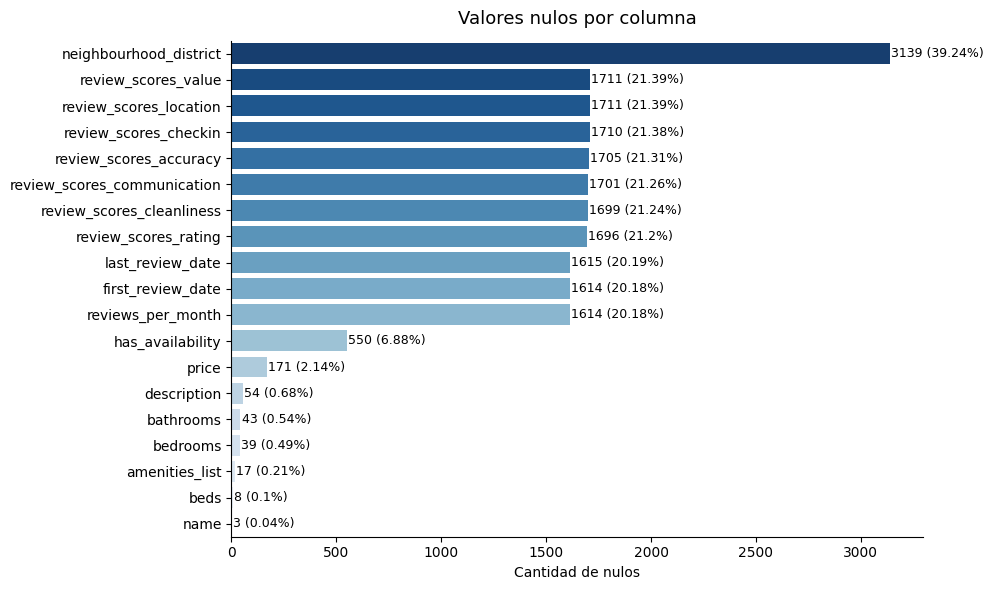

In [ ]:
# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=missing_data['Valores nulos'], y=missing_data.index, palette='Blues_r', ax=ax)
for i, (val, pct) in enumerate(zip(missing_data['Valores nulos'], missing_data['Porcentaje (%)'])):
    ax.text(val + 5, i, f"{val} ({pct}%)", va='center', fontsize=9)
ax.set_title("Valores nulos por columna", fontsize=13, pad=12)
ax.set_xlabel("Cantidad de nulos")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Nulos en variables relevantes para ambos equipos
cols_relevantes = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'price', 'accommodates', 'bedrooms', 'beds',
    'bathrooms', 'neighbourhood_district', 'room_type', 'city'
]
nulos_rel = df_alojamientos[cols_relevantes].isnull().sum()
pct_rel = (nulos_rel / len(df_alojamientos) * 100).round(2)
pd.DataFrame({'Valores nulos': nulos_rel, 'Porcentaje (%)': pct_rel})

,Valores nulos,Porcentaje (%)
review_scores_rating,1696,21.20
review_scores_accuracy,1705,21.31
review_scores_cleanliness,1699,21.24
review_scores_checkin,1710,21.38
review_scores_communication,1701,21.26
review_scores_location,1711,21.39
review_scores_value,1711,21.39
price,171,2.14
accommodates,0,0.00
bedrooms,39,0.49


**Observaciones — Valores nulos:**

- `city`, `room_type`, `accommodates`, `price` y `beds`: sin nulos o con impacto muy bajo ✅
- Las variables `review_scores_*` tienen ~21% de nulos — alojamientos sin reseñas (nuevos o inactivos). No es un error de datos.
- `neighbourhood_district` tiene el mayor porcentaje de nulos (~39%) — limita el análisis por ubicación por distrito. `neighbourhood_name` no tiene nulos y puede utilizarse como alternativa.
- `bathrooms` y `bedrooms`: pocos nulos pero con problema de tipo de dato (varchar).

> ⚠️ Estrategia de imputación a definir en el notebook de limpieza.

## 6. Descripción estadística

Calculamos media, mediana, moda y desviación estándar para las variables numéricas.

In [ ]:
# Estadísticas descriptivas ampliadas: media, mediana, moda, std
numerical_cols = df_alojamientos.select_dtypes(include=[np.number])
stats = numerical_cols.describe().transpose()
stats['median'] = numerical_cols.median()
stats['mode'] = numerical_cols.mode().iloc[0]
stats[['mean', 'median', 'mode', 'std', 'min', 'max']].round(2)

,mean,median,mode,std,min,max
apartment_id,16965762.19,18075218.5,10005342.0,8733606.94,11964.0,32423292.0
host_id,70865589.85,48353053.0,80839530.0,65751851.98,10704.0,336524176.0
accommodates,4.33,4.0,2.0,2.59,1.0,29.0
beds,2.97,2.0,1.0,2.29,0.0,30.0
price,1007.75,750.0,600.0,844.35,60.0,6071.0
minimum_nights,4.57,2.0,1.0,11.81,1.0,365.0
maximum_nights,761.23,1125.0,1125.0,497.95,1.0,1125.0
availability_30,12.39,10.0,0.0,11.52,0.0,30.0
availability_60,27.61,27.0,0.0,22.41,0.0,60.0
availability_90,44.60,47.0,0.0,33.00,0.0,90.0


**Observaciones — Estadísticas descriptivas:**

- **`review_scores_rating`**: media 919/1000, mediana 940 — distribución sesgada hacia valoraciones altas. La moda es 1000, lo que indica que muchos alojamientos tienen la puntuación máxima.
- **`review_scores_*` (dimensiones)**: todas en escala 0-100, medias entre 91-96 y moda 100 — calidad consistentemente alta. `review_scores_value` es la más baja (media 91.4).
- **`price`**: media 1.007€, mediana 750€ — alta dispersión (std 844). La mediana es más representativa por la presencia de alojamientos de lujo con precios muy elevados (máximo 6.071€).
- **`number_of_reviews`**: alta variabilidad (std 57, máximo 588) — algunos alojamientos muy activos, muchos con 0 reseñas.
- **`reviews_per_month`**: media 125 pero mediana 58 — distribución muy asimétrica.
- **`apartment_id`** y **`host_id`**: son identificadores, no tiene sentido interpretarlos estadísticamente.

> ⚠️ `reviews_per_month` con media 125 y máximo 1291 parece estar en una escala inesperada — verificar con el equipo de datos.

## 7. EDA automático con Sweetviz

Sweetviz genera un informe HTML interactivo con estadísticas, distribuciones y correlaciones de todas las variables. Útil como punto de partida para identificar rápidamente patrones y variables a investigar.

In [ ]:
# EDA automático con Sweetviz
report = sv.analyze(df_alojamientos)
report.show_html('EDA_sweetviz_28_04.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report EDA_sweetviz_28_04.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Sweetviz genera automáticamente un informe HTML interactivo con estadísticas descriptivas, distribuciones, correlaciones y valores nulos de todas las variables del dataset. Se utiliza como punto de partida para identificar rápidamente patrones antes de profundizar en el análisis.

## 8. Distribuciones de variables numéricas

Histogramas de todas las variables numéricas para detectar asimetrías, bimodalidad y posibles outliers.

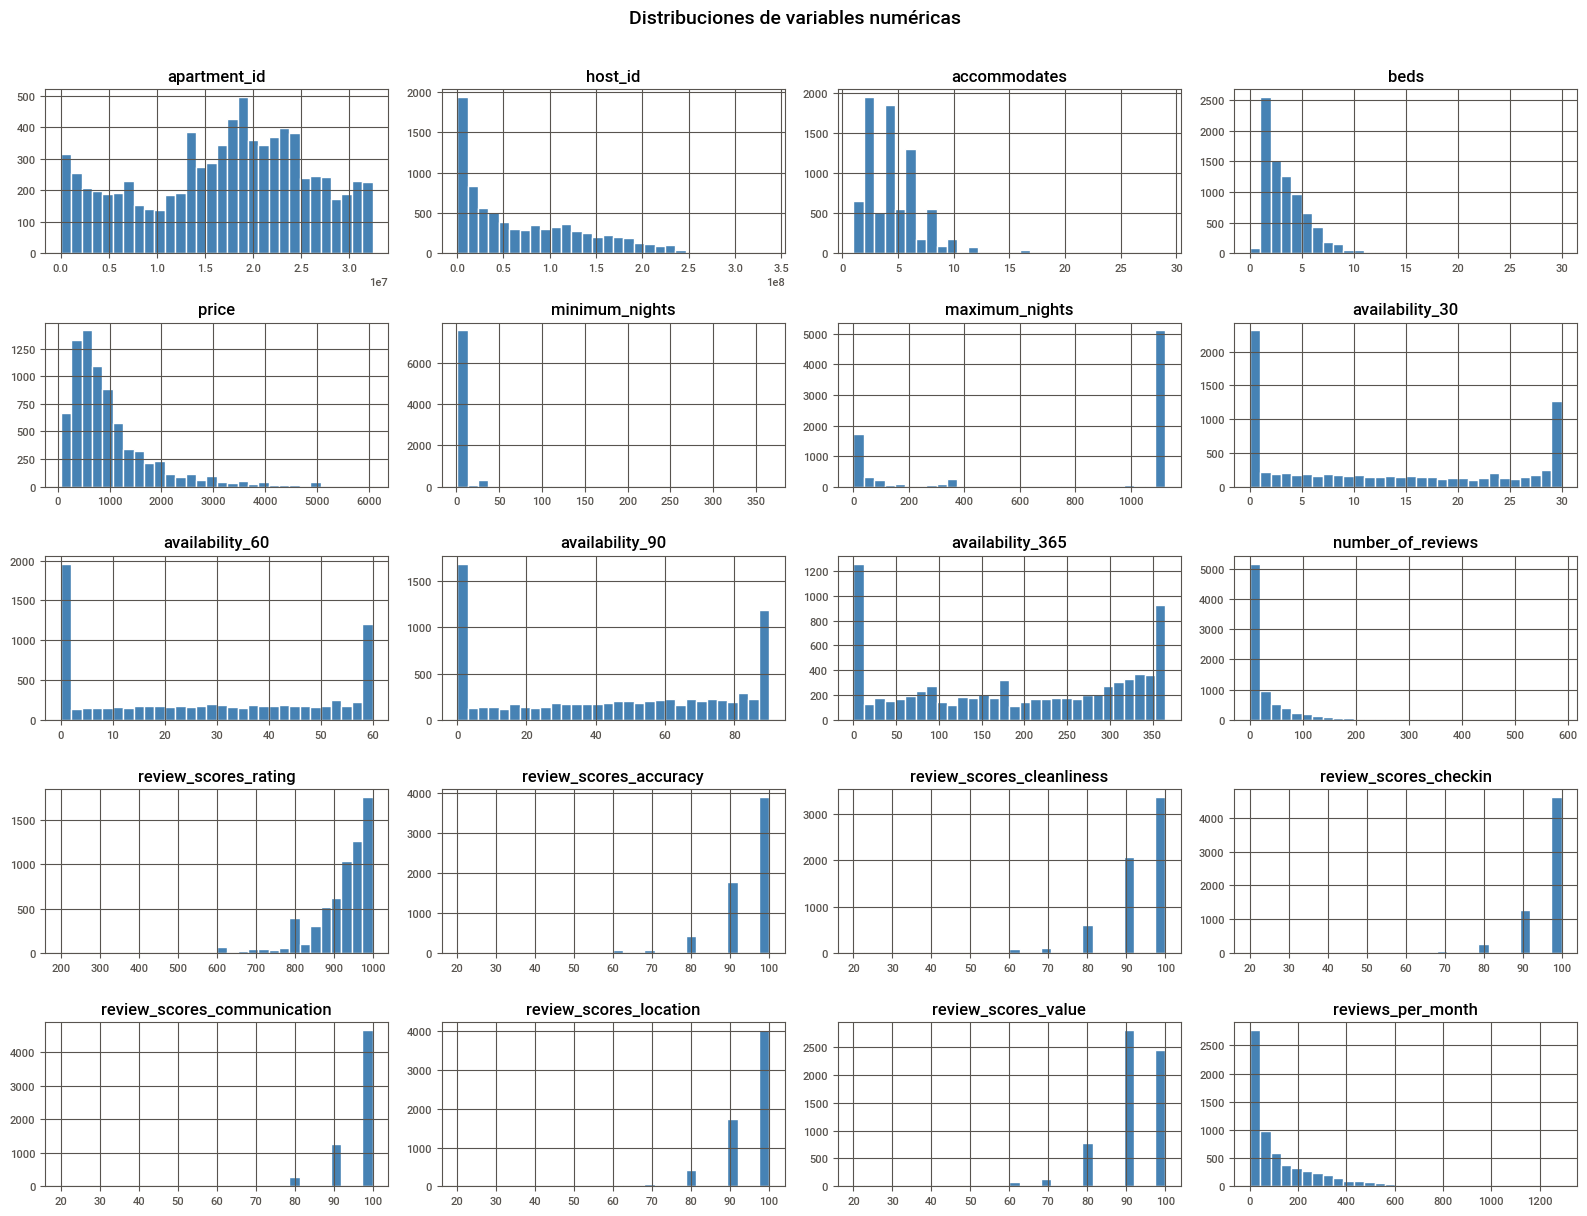

In [ ]:
# Histogramas de todas las variables numéricas
numerical_cols.hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='white')
plt.suptitle("Distribuciones de variables numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones — Distribuciones de variables numéricas:**

- **`accommodates` y `beds`**: la mayoría de alojamientos tienen capacidad para 2-4 personas, con pico en 2. Oferta orientada principalmente a parejas y grupos pequeños.
- **`price`**: distribución asimétrica con cola derecha larga. La mayoría de alojamientos se sitúan entre 500 y 1.500€, aunque existen casos extremos que llegan hasta 6.000€.
- **`minimum_nights`**: la gran mayoría exige 1-2 noches mínimo, con muy pocos casos atípicos de estancias largas.
- **`maximum_nights`**: pico masivo en 1125 — parece un valor por defecto del sistema más que un dato real. ⚠️
- **`availability_*`**: distribuciones bimodales en todos los períodos — los alojamientos tienden a estar completamente disponibles o completamente ocupados, con poca zona intermedia.
- **`number_of_reviews`**: distribución exponencial — la mayoría tienen pocas reseñas y unos pocos acumulan cientos.
- **`review_scores_*`** (dimensiones): muy concentradas en valores altos (90-100) — la oferta está generalemente bien valorada en todas las dimensiones.
- **`review_scores_rating`**: distribución sesgada hacia valores altos, con una pequeña cola izquierda de alojamientos peor valorados.
- Ninguna variable sigue una distribución normal.

## 9. Distribuciones de variables categóricas

Frecuencia de cada categoría en las variables categóricas relevantes.

/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/3933596481.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='Blues_r', ax=axes[i])
/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/3933596481.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette='Blues_r', ax=axes[i])
/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/3933596481.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palet

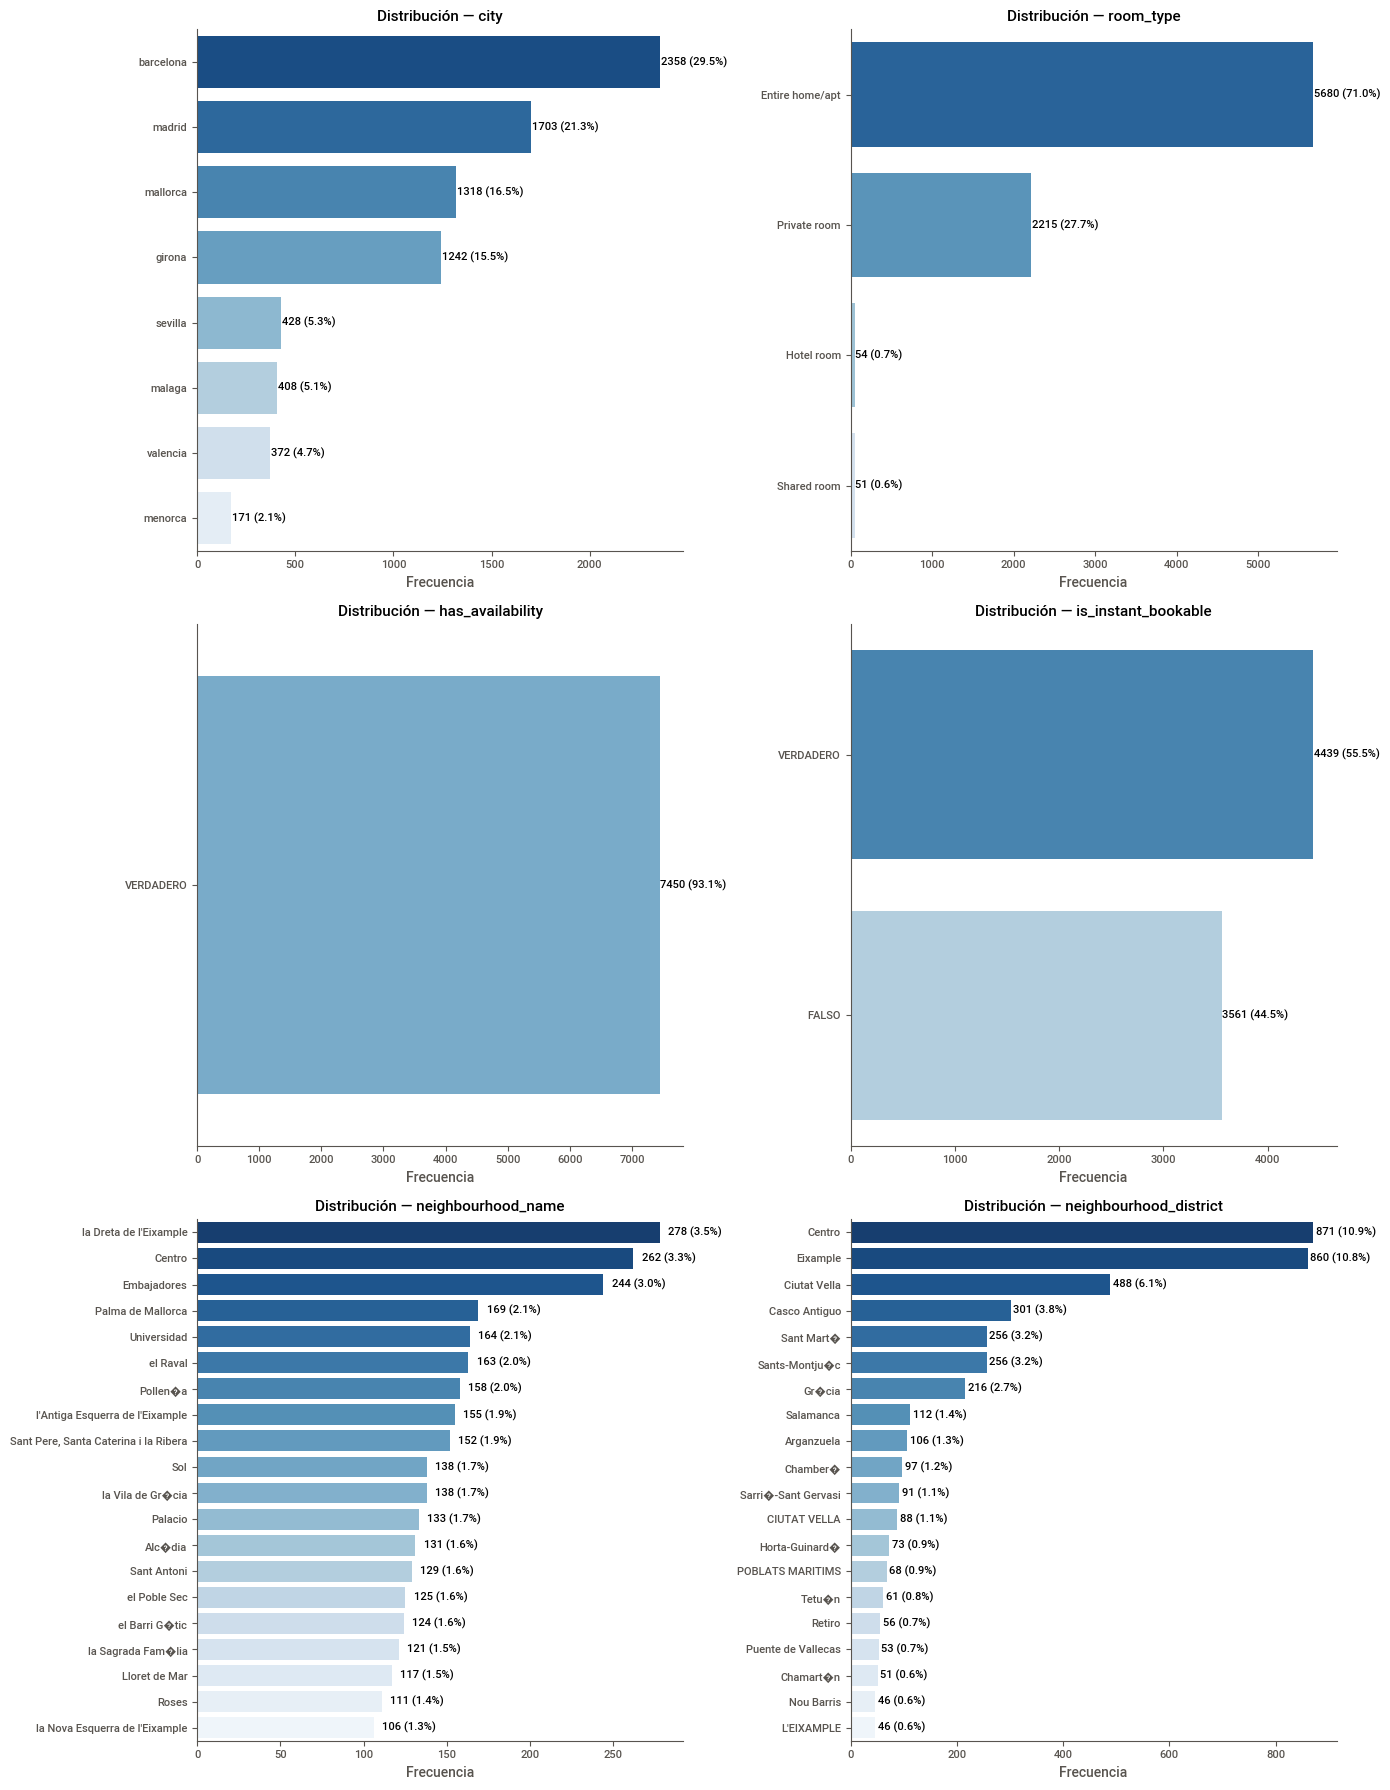

In [ ]:
# Distribución de variables categóricas relevantes
cat_cols = ['city', 'room_type', 'has_availability', 'is_instant_bookable', 'neighbourhood_name', 'neighbourhood_district']

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_alojamientos[col].value_counts().head(20)
    sns.barplot(x=counts.values, y=counts.index, palette='Blues_r', ax=axes[i])
    for j, val in enumerate(counts.values):
        pct = val / len(df_alojamientos) * 100
        axes[i].text(val + 5, j, f"{val} ({pct:.1f}%)", va='center', fontsize=8)
    axes[i].set_title(f"Distribución — {col}", fontsize=11)
    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel("")
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

**Observaciones — Variables categóricas:**

- **`city`**: Barcelona concentra casi el 30% de los alojamientos, seguida de Madrid (21%) y Mallorca (16.5%). Menorca es la ciudad menos representada (2.1%) — comparaciones estadísticas con ciudades pequeñas deben interpretarse con cautela.
- **`room_type`**: el 71% son alojamientos completos (Entire home/apt). Habitaciones de hotel y compartidas son marginales (<1%).
- **`has_availability`**: el 93% de los alojamientos tiene disponibilidad activa.
- **`is_instant_bookable`**: distribución equilibrada — 55.5% permiten reserva instantánea.
- **`neighbourhood_district`**: Centro y Eixample son los distritos más representados. Se observan inconsistencias en los nombres (ej: "Ciutat Vella" y "CIUTAT VELLA" como categorías separadas) — requiere limpieza. ⚠️

## 10. Detección de outliers

El método IQR (rango intercuartílico) permite detectar outliers de forma automática y objetiva, sin definir umbrales manualmente. Se calcula la distancia entre el percentil 25 (Q1) y el percentil 75 (Q3) de cada variable — el rango donde se concentra el 50% central de los datos. Un valor se considera outlier si está por debajo de Q1 - 1.5×IQR o por encima de Q3 + 1.5×IQR.

In [ ]:
# Detección de outliers con método IQR
def detectar_outliers_iqr(data):
    outliers = {}
    for col in data.select_dtypes(include=[np.number]).columns:
        Q1 = data[col].dropna().quantile(0.25)
        Q3 = data[col].dropna().quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        outliers[col] = n_outliers
    return pd.Series(outliers)

outliers_count = detectar_outliers_iqr(df_alojamientos)
outliers_pct = (outliers_count / len(df_alojamientos) * 100).round(2)
outliers_df = pd.DataFrame({
    'Nº outliers': outliers_count,
    'Porcentaje (%)': outliers_pct
}).sort_values('Nº outliers', ascending=False)
outliers_df[outliers_df['Nº outliers'] > 0]

,Nº outliers,Porcentaje (%)
number_of_reviews,827,10.34
price,597,7.46
minimum_nights,447,5.59
reviews_per_month,397,4.96
review_scores_value,264,3.30
review_scores_rating,254,3.18
review_scores_cleanliness,251,3.14
review_scores_accuracy,190,2.38
beds,183,2.29
review_scores_checkin,122,1.52


/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/893769745.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/893769745.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outliers_plot.index, y=outliers_plot['Nº outliers'], palette='Blues_r', ax=axes[1])
/var/folders/vk/kwrzr2bd3ld451r5dkl52md80000gn/T/ipykernel_2601/893769745.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


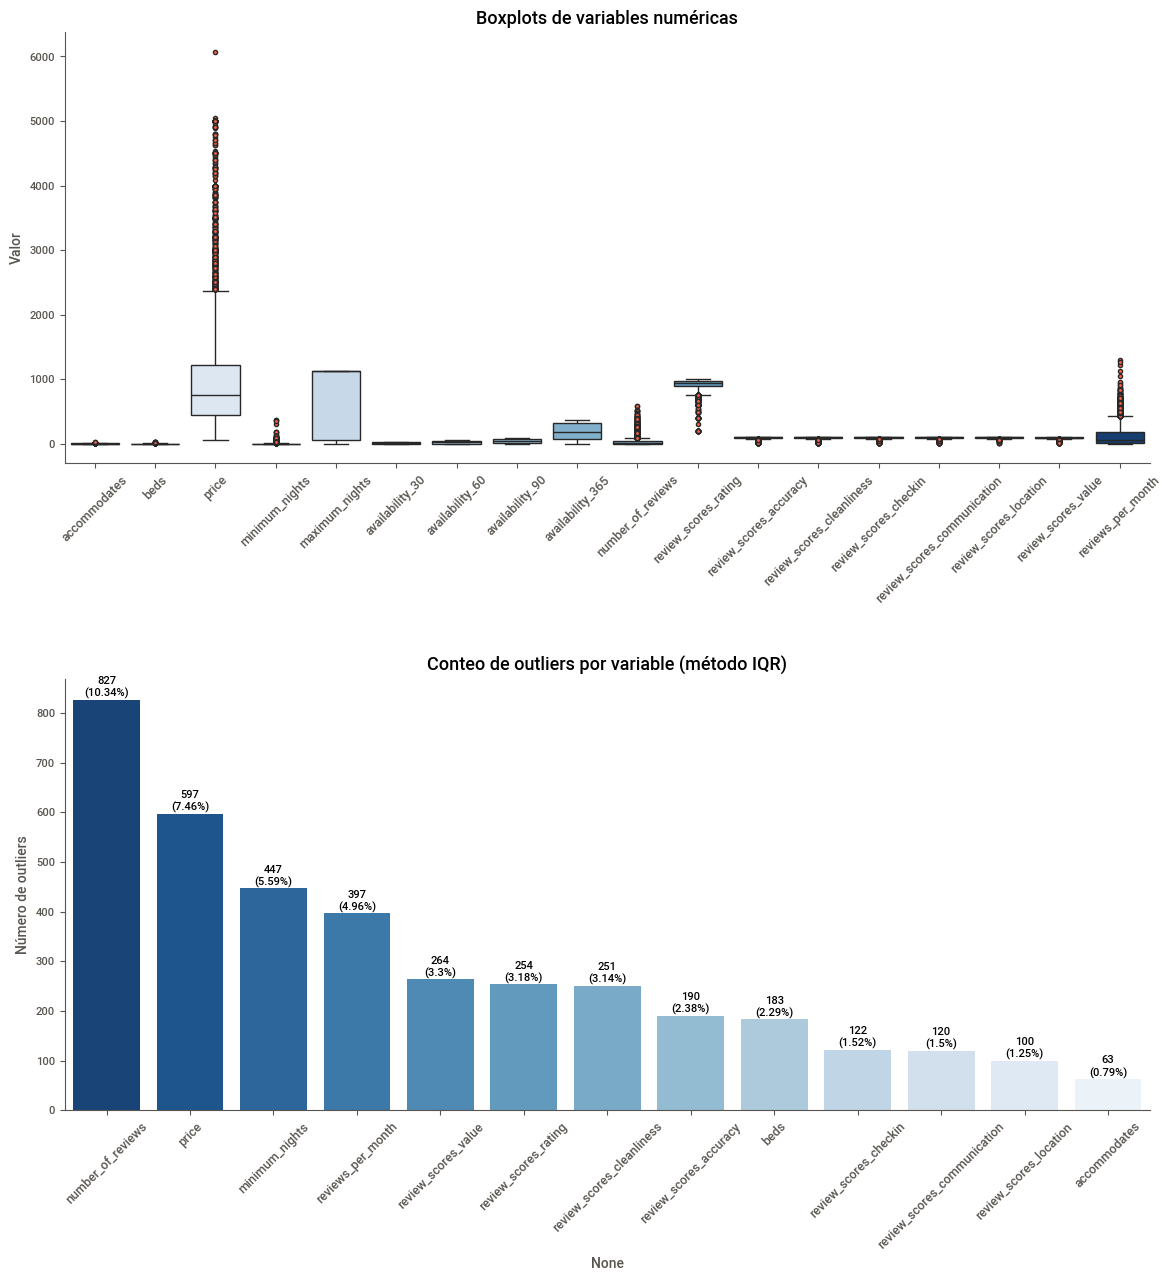

In [ ]:
# Boxplots + conteo de outliers
fig, axes = plt.subplots(2, 1, figsize=(14, 14), gridspec_kw={'hspace': 0.5})

# Excluimos IDs — no tienen sentido estadístico
num_data = df_alojamientos.select_dtypes(include=[np.number]).drop(columns=['apartment_id', 'host_id'])
melted = num_data.reset_index().melt(id_vars=['index'], var_name='Variable', value_name='Valor')
sns.boxplot(
    x='Variable', y='Valor', data=melted, palette='Blues',
    flierprops={'marker': 'o', 'markerfacecolor': 'tomato', 'markersize': 3}, ax=axes[0]
)
axes[0].set_title("Boxplots de variables numéricas", fontsize=13)
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
sns.despine(ax=axes[0])

# Excluimos IDs también del conteo de outliers
outliers_plot = outliers_df[
    (outliers_df['Nº outliers'] > 0) & 
    (~outliers_df.index.isin(['apartment_id', 'host_id']))
]
sns.barplot(x=outliers_plot.index, y=outliers_plot['Nº outliers'], palette='Blues_r', ax=axes[1])
for idx, (val, pct) in enumerate(zip(outliers_plot['Nº outliers'], outliers_plot['Porcentaje (%)'])):
    if val > 0:
        axes[1].text(idx, val + 1, f"{val}\n({pct}%)", ha='center', va='bottom', fontsize=8)
axes[1].set_title("Conteo de outliers por variable (método IQR)", fontsize=13)
axes[1].set_ylabel("Número de outliers")
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Observaciones — Boxplots:**

- **`price`**: gran cantidad de outliers hacia arriba — alojamientos de lujo con precios muy superiores a la media. No son errores de datos.
- **`maximum_nights`**: caja muy amplia — alta variabilidad, probablemente relacionada con el valor por defecto 1125 detectado anteriormente. ⚠️
- **`review_scores_rating`**: caja pequeña y concentrada en valores altos, con pocos outliers a la baja — la mayoría de alojamientos están bien valorados.
- **`reviews_per_month`**: cola larga hacia arriba con outliers extremos — requiere verificación. ⚠️
- Las dimensiones `review_scores_*` presentan cajas muy compactas — baja dispersión y calidad consistente en todas las variables de valoración.


## 11. Correlaciones

Correlaciones entre variables numéricas relevantes para ambos equipos.

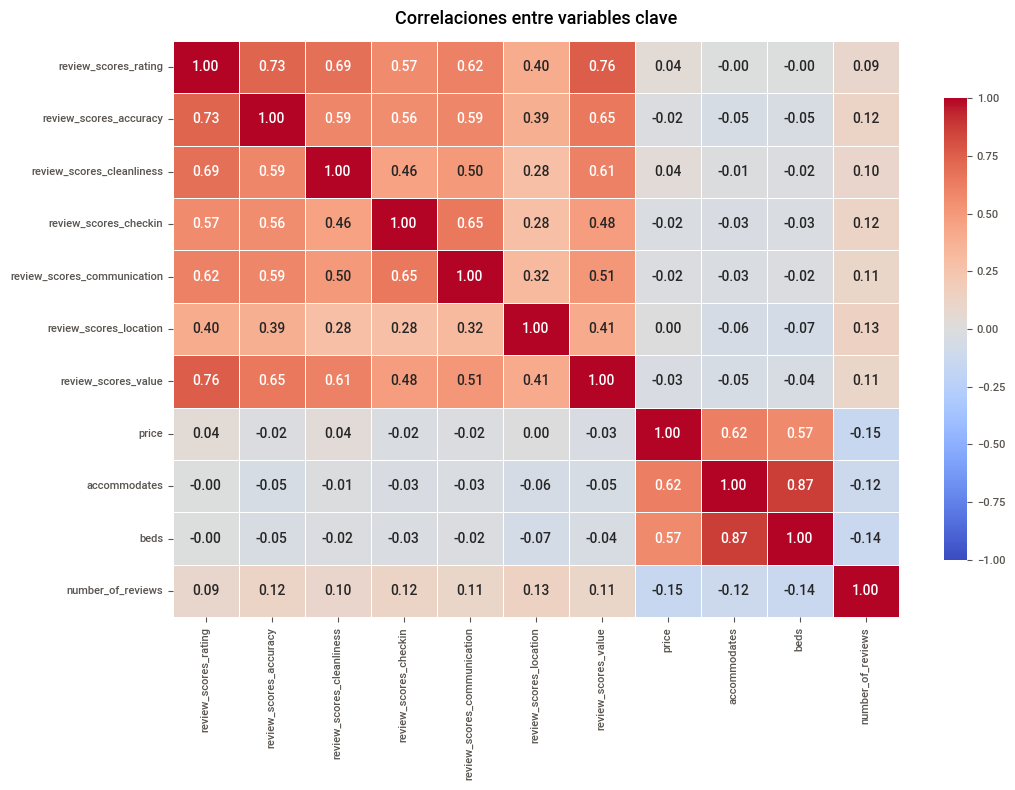

In [ ]:
# Heatmap de correlaciones
cols_corr = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'price', 'accommodates', 'beds', 'number_of_reviews'
]

corr_matrix = df_alojamientos[cols_corr].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title("Correlaciones entre variables clave", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [ ]:
# Correlaciones con las dos variables objetivo
corr_rating = corr_matrix['review_scores_rating'].drop('review_scores_rating').sort_values(ascending=False)
print("Correlaciones con review_scores_rating:")
print(corr_rating.round(3))
print()
corr_price = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("Correlaciones con price:")
print(corr_price.round(3))

Correlaciones con review_scores_rating:
review_scores_value            0.765
review_scores_accuracy         0.734
review_scores_cleanliness      0.685
review_scores_communication    0.615
review_scores_checkin          0.568
review_scores_location         0.400
number_of_reviews              0.090
price                          0.041
beds                          -0.001
accommodates                  -0.005
Name: review_scores_rating, dtype: float64

Correlaciones con price:
accommodates                   0.620
beds                           0.575
review_scores_rating           0.041
review_scores_cleanliness      0.038
review_scores_location         0.002
review_scores_communication   -0.017
review_scores_accuracy        -0.018
review_scores_checkin         -0.024
review_scores_value           -0.033
number_of_reviews             -0.155
Name: price, dtype: float64


**Observaciones — Correlaciones:**

- **`review_scores_value`** (0.76) y **`review_scores_accuracy`** (0.73) son las dimensiones con mayor correlación con el rating general.
- **`review_scores_location`** (0.40) tiene la correlación más baja — la ubicación no penaliza tanto la valoración general.
- **`price`** tiene correlación casi nula con el rating (0.04) — un alojamiento caro no garantiza mejor valoración.
- **`accommodates`** (0.62) y **`beds`** (0.57) correlacionan positivamente con el precio — a mayor capacidad, mayor precio.
- **`number_of_reviews`** correlaciona negativamente con el precio (-0.15) — los alojamientos más económicos tienden a acumular más reseñas.

## 12. Conclusiones

### Calidad de los datos
- El dataset contiene 7.693 registros y 35 columnas.
- Las variables `review_scores_*` presentan ~21% de nulos — alojamientos sin reseñas. No es un error de datos.
- `neighbourhood_district` tiene el mayor porcentaje de nulos (~39%) — limita el análisis por ubicación detallada. `neighbourhood_name` no tiene nulos y puede utilizarse como alternativa.
- Ninguna variable sigue una distribución normal — típico en datos de plataformas de alojamiento turístico.

### Hallazgos generales
- Barcelona concentra el 30% de los alojamientos. Menorca es la ciudad menos representada (2.1%).
- El 71% de los alojamientos son Entire home/apt. Habitaciones compartidas y de hotel son marginales (<1%).
- El 93% de los alojamientos tiene disponibilidad activa.
- `accommodates` y `beds` correlacionan fuertemente entre sí (0.87) — la capacidad y el número de camas van de la mano.

### Hallazgos — Marketing y Estrategia Comercial
- `accommodates` (0.62) es el factor que más correlaciona con el precio — a mayor capacidad, mayor precio.
- `beds` también correlaciona con el precio (0.57) — muy ligado a `accommodates` (correlación entre ambos: 0.87).
- `number_of_reviews` correlaciona negativamente con el precio (-0.15) — los alojamientos más económicos acumulan más reseñas.
- El precio no correlaciona con las valoraciones (0.04) — calidad y precio son independientes.
- La distribución de precios es muy asimétrica: mediana 750€, media 1.007€, máximo 6.071€ — presencia de alojamientos de lujo que elevan la media.
- Mallorca y Barcelona son las ciudades con precios más elevados según la exploración inicial.
- `neighbourhood_district` tiene un 39% de nulos — usar `neighbourhood_name` (0 nulos) para el análisis de ubicación.
- Los equipamientos (`amenities_list`) no se han podido analizar en la EDA — requieren parseo previo para extraer variables útiles.

### Hallazgos — Experiencia del Cliente
- Usar `review_scores_rating_clean` (escala 0-100) para el análisis — no `review_scores_rating` (escala 0-1000).
- `review_scores_value` (0.76) y `review_scores_accuracy` (0.73) son las dimensiones con mayor correlación con el rating general.
- `review_scores_location` (0.40) es la dimensión con menor correlación con el rating.
- El precio tiene correlación casi nula con el rating (0.04) — pagar más no garantiza mejor valoración.
- Segmentación por cuartiles: Q1 = 89, Q3 = 98 sobre `review_scores_rating_clean`.

### Alertas para el equipo de limpieza ⚠️

- `bathrooms` y `bedrooms` son varchar en el dataset raw — contienen texto como "1 bath" o "Studio". Requieren extracción del valor numérico.
- `neighbourhood_district` presenta inconsistencias en los nombres (ej: "Ciutat Vella" vs "CIUTAT VELLA", "Eixample" vs "L'EIXAMPLE") — requiere estandarización antes del análisis.
- `maximum_nights` tiene un pico masivo en 1125 — posible valor por defecto del sistema, verificar.
- `has_availability` e `is_instant_bookable` son varchar con valores `t`/`f` — pendiente de conversión a booleano.
- `first_review_date`, `last_review_date` e `insert_date` son varchar — pendiente de conversión a tipo fecha.
- `amenities_list` requiere parseo previo antes de poder usarse como variable analítica.
- `price` tiene 159 nulos — usar `price_imputed` para el análisis de Marketing.
- `review_scores_rating` está en escala 0-1000 — convertir a escala 0-100 (`review_scores_rating_clean`) antes del análisis.Want to be notified when Claude responds?NotifySonnet 4.6Claude is AI and can make mistakes. Please double-check responses.Eda 27 04 · IPYNBCopyNo file content available